# Exploratory Data Analysis
## ESPN CFB Win Probability Calibration Study

Quick look at the data before diving into calibration analysis.

In [10]:
import sys; sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

games_df = pd.read_parquet(PROCESSED_DIR / "games.parquet")
plays_df = pd.read_parquet(PROCESSED_DIR / "plays.parquet")

print(f"Games:  {len(games_df):,}")
print(f"Plays:  {len(plays_df):,}")
print(f"Seasons: {sorted(plays_df.season.dropna().unique().astype(int))}")


Games:  14,100
Plays:  2,441,460
Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [11]:
games_df.columns

Index(['game_id', 'season', 'season_type', 'season_type_id', 'week', 'date',
       'home_team', 'home_team_id', 'home_team_abbr', 'home_score_final',
       'away_team', 'away_team_id', 'away_team_abbr', 'away_score_final',
       'neutral_site', 'attendance', 'venue_name', 'venue_city', 'venue_state',
       'weather_temp_f', 'weather_condition', 'weather_wind_speed',
       'weather_wind_direction', 'weather_humidity', 'espn_home_prob_pregame',
       'espn_spread', 'espn_over_under', 'home_conference', 'away_conference',
       'group', 'actual_home_win', 'went_to_overtime', 'pre_game_spread',
       'over_under'],
      dtype='str')

## Games per Season

In [12]:
season_counts = plays_df.groupby("season").agg(
    games=("game_id", "nunique"),
    plays=("play_id", "count"),
    pct_with_wp=("home_win_prob", lambda x: x.notna().mean()),
).reset_index()

season_counts["plays_per_game"] = (season_counts["plays"] / season_counts["games"]).round(1)
season_counts["pct_with_wp"] = (season_counts["pct_with_wp"] * 100).round(1)
print(season_counts.to_string(index=False))


 season  games  plays  pct_with_wp  plays_per_game
   2015      2     19        100.0             9.5
   2016   1432 258384        100.0           180.4
   2017   1484 264384        100.0           178.2
   2018   1455 260819        100.0           179.3
   2019   1554 274138        100.0           176.4
   2020    584 105150        100.0           180.1
   2021   1405 236924        100.0           168.6
   2022   1416 228092        100.0           161.1
   2023   1517 254568        100.0           167.8
   2024   1585 268987        100.0           169.7
   2025   1666 289995        100.0           174.1


In [13]:
pd.set_option('display.max_columns', None)
example_game = plays_df[(plays_df['season']==2025) & (plays_df['game_id']=='401762503')].sort_values(['period', 'total_seconds_elapsed'], ascending=[True, True])

In [14]:
[t for t in plays_df['home_team'].unique() if 'ohio' in t.lower()] 

['Ohio Bobcats', 'Ohio State Buckeyes']

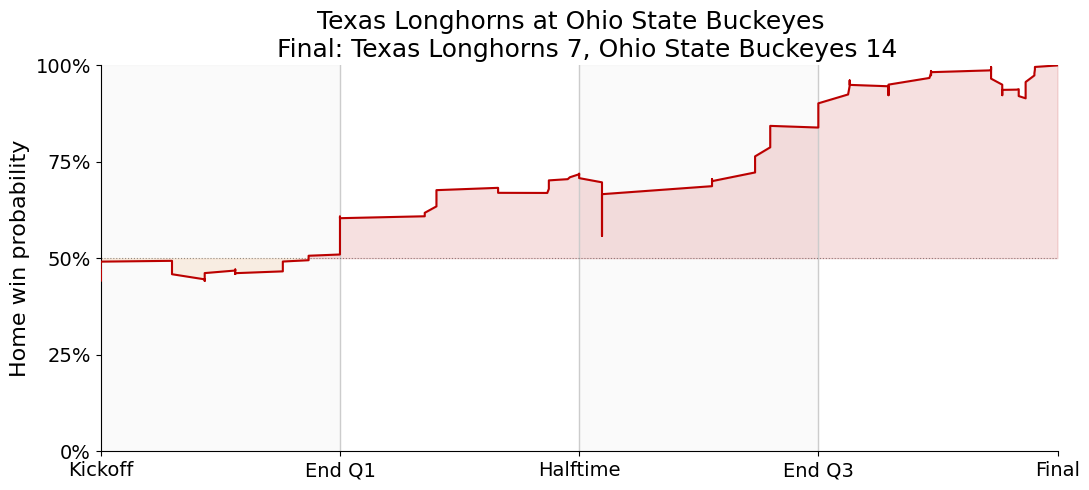

In [48]:
from scipy.signal import savgol_filter                
                                                      
subset_plays = plays_df[(plays_df['home_team'] ==     
'Ohio State Buckeyes') & (plays_df['season'] == 2025)]
game_id = subset_plays["game_id"].unique()[0]  # swap in a specific game_id if you want a better trace      
game = subset_plays[subset_plays["game_id"] ==
game_id].sort_values("total_seconds_elapsed")         
                
home = game["home_team"].iloc[0]                      
away = game["away_team"].iloc[0]
                                                      
game_row = games_df[games_df["game_id"] ==
game_id].iloc[0]                                      
home_score = int(game_row["home_score_final"])
away_score = int(game_row["away_score_final"])        
  
HOME_COLOR ="#BB0000"                                
                
fig, ax = plt.subplots(figsize=(11, 5))               
                
x = game["total_seconds_elapsed"]                     
y_raw = game["home_win_prob"].values
y = savgol_filter(y_raw, window_length=10,polyorder=2).clip(0, 1)                               
ax.fill_between(x, y, 0.5, where=(y >= 0.5),          
color=HOME_COLOR, alpha=0.12, interpolate=True)
ax.fill_between(x, y, 0.5, where=(y < 0.5),           
color="#EB7D1745",  alpha=0.10, interpolate=True)       
  
for i, (start, end) in enumerate([(0, 900), (900,     
1800), (1800, 2700), (2700, 3600)]):
    if i % 2 == 0:                                    
        ax.axvspan(start, end, color="gray",          
alpha=0.04, zorder=0)                                 
                                                      
for q in [900, 1800, 2700]:                           
    ax.axvline(q, color="#cccccc", linewidth=1.0,
zorder=1)                                             
  
ax.axhline(0.5, color="black", linewidth=0.8,         
linestyle=":", alpha=0.4)
ax.plot(x, y, color=HOME_COLOR, linewidth=1.5,          
solid_capstyle="round", zorder=3)                     
  
ax.set_xlim(0, game["total_seconds_elapsed"].max())   
ax.set_ylim(0, 1)
ax.set_ylabel("Home win probability", fontsize=16)
ax.set_title(f"{away} at {home}  \n  Final: {away} {away_score}, {home} {home_score}", fontsize=18)      
ax.set_xticks([0, 900, 1800, 2700, 3600])             
ax.set_xticklabels(["Kickoff", "End Q1", "Halftime",  
"End Q3", "Final"], fontsize = 14)                                   
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])              
ax.set_yticklabels(["0%", "25%", "50%", "75%",        
"100%"], fontsize = 14)        
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Win Probability Distribution

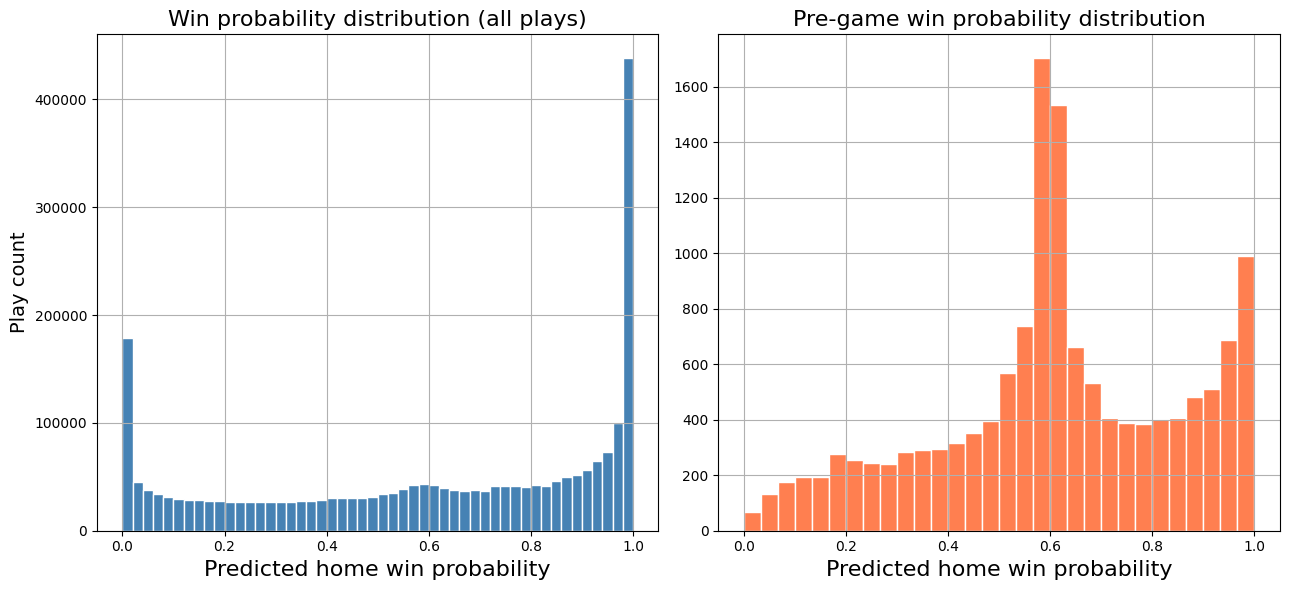

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Overall distribution
plays_df["home_win_prob"].dropna().hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Predicted home win probability", fontsize = 16)
axes[0].set_ylabel("Play count", fontsize = 14)
axes[0].set_title("Win probability distribution (all plays)", fontsize = 16)

# Pre-game only (first play of each game)
pregame = plays_df.sort_values("total_seconds_elapsed").groupby("game_id").first()
pregame["home_win_prob"].dropna().hist(bins=30, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_xlabel("Predicted home win probability", fontsize = 16)
axes[1].set_title("Pre-game win probability distribution", fontsize = 16)

plt.tight_layout()
plt.show()


# Why the spike at 0.6? 

## Outcome Distribution

In [8]:
# What fraction of plays come from home-team wins?
win_rate = pregame["actual_home_win"].mean()
print(f"Overall home win rate: {win_rate:.1%}")
print()
print("Plays by season type:")
print(plays_df.groupby("season_type")["game_id"].nunique().sort_values(ascending=False))


Overall home win rate: 61.1%

Plays by season type:
season_type
regular       13645
postseason      441
offseason        14
Name: game_id, dtype: int64


- Average true win rate is around where the spike is 
- I suspect this is some kind of prior average for low information games. 



In [9]:
pregame = pregame.copy()
pregame["near_0.6"] = pregame["home_win_prob"].between(0.59, 0.61)
print(f"near_0.6: {pregame['near_0.6'].sum():,} games  |  other: {(~pregame['near_0.6']).sum():,} games\n")

cat_vars = ["conference_tier_home", "group"]
for col in cat_vars:
    ct = pd.crosstab(pregame[col], pregame["near_0.6"])
    ct.columns = ["Other", "Near 0.6"]
    ct["pct_near_0.6"] = (ct["Near 0.6"] / ct.sum(axis=1) * 100).round(1)
    ct = ct.sort_values("pct_near_0.6", ascending=False).head(10)
    print(f"--- {col} ---")
    print(ct.to_string())
    print()

# Attendance (in games_df, merge in)
print("--- attendance ---")
print(pregame.groupby("near_0.6")["attendance"].describe().round(0).T.to_string())

near_0.6: 1,206 games  |  other: 12,894 games

--- conference_tier_home ---
                      Other  Near 0.6  pct_near_0.6
conference_tier_home                               
G5_or_FCS              8445      1103          11.6
P5                     4449       103           2.3

--- group ---
       Other  Near 0.6  pct_near_0.6
group                               
81      5326       979          15.5
80      7568       227           2.9

--- attendance ---
near_0.6     False     True 
count      12894.0    1206.0
mean       27743.0   12413.0
std        26971.0   16234.0
min            0.0       0.0
25%         6820.0    3641.0
50%        18096.0    6779.0
75%        43012.0   13783.0
max       156990.0  109835.0


Group 80 = FBS, Group 81 = FCS (and below).

Group 80 has Power Five teams (SEC, Big 12) and G5 teams (CUSA) — all FBS. Group 81 has Austin Peay, Samford, NDSU, Columbia — all FCS programs. This is ESPN's grouping ID for the subdivision level, not the conference. 

## Score Differential Distribution

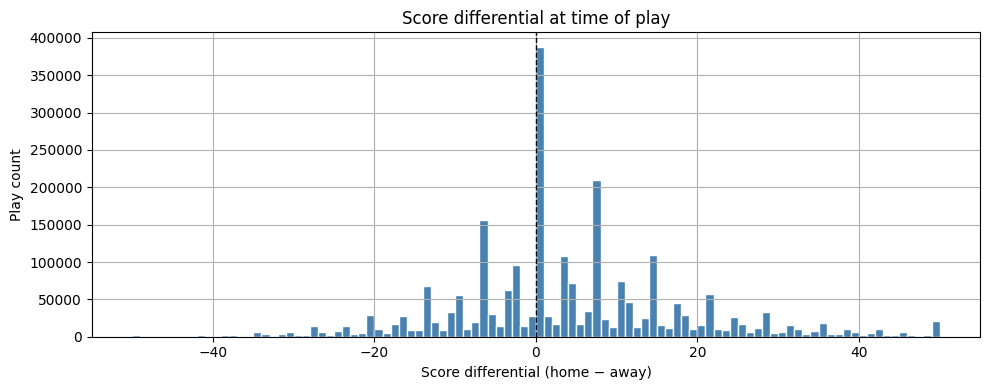

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
plays_df["score_differential"].clip(-50, 50).hist(bins=100, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Score differential (home − away)")
ax.set_ylabel("Play count")
ax.set_title("Score differential at time of play")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
plt.tight_layout()
plt.show()


## Plays by Game Clock

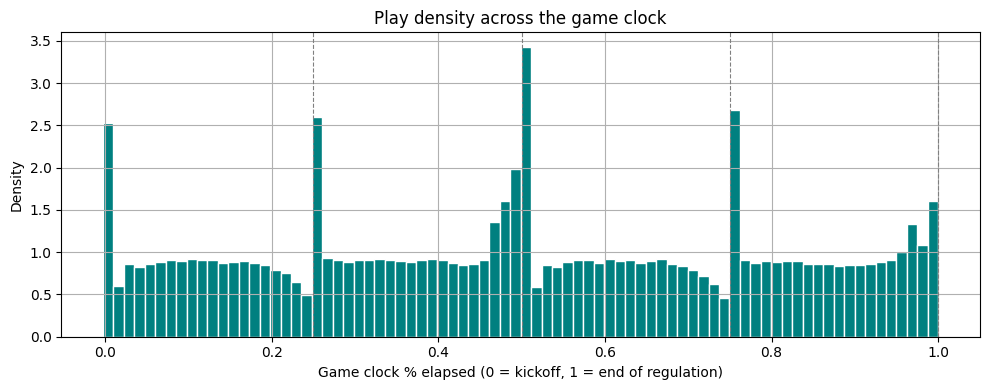

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
plays_df["game_clock_pct"].dropna().hist(bins=80, ax=ax, color="teal", edgecolor="white", density=True)
ax.set_xlabel("Game clock % elapsed (0 = kickoff, 1 = end of regulation)")
ax.set_ylabel("Density")
ax.set_title("Play density across the game clock")
for q in [0.25, 0.5, 0.75, 1.0]:
    ax.axvline(q, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()


## Conference Tier Coverage

In [12]:
tier_counts = plays_df.groupby("conference_tier_home")["game_id"].nunique()
print("Games by home team conference tier:")
print(tier_counts.sort_values(ascending=False))


Games by home team conference tier:
conference_tier_home
G5_or_FCS    9548
P5           4552
Name: game_id, dtype: int64


## Overtime Games

In [13]:
ot_games = games_df[games_df["went_to_overtime"] == True]
print(f"Games with overtime: {len(ot_games):,} ({len(ot_games)/len(games_df):.1%})")
ot_plays = plays_df[plays_df["is_overtime"] == True]
print(f"OT plays: {len(ot_plays):,} ({len(ot_plays)/len(plays_df):.1%})")


Games with overtime: 535 (3.8%)
OT plays: 5,738 (0.2%)


## Missing Data Audit

In [14]:
print("Missing value rates in plays_df:")
missing = (plays_df.isna().sum() / len(plays_df) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(2).to_string())


Missing value rates in plays_df:
weather_temp_f                 100.00
week                           100.00
over_under                      58.48
pre_game_spread                 49.71
implied_home_win_prob_vegas     49.71
spread_category                 49.71
score_differential_bin           0.00
game_clock_bin                   0.00
